<a href="https://www.kaggle.com/code/mashrur135/nb-dinov2?scriptVersionId=341751622" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Task B — DINOv2 Pretraining
### CSE 438 Part B — SSL for Semantic Segmentation



In [1]:
import os, time, json, random, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


## Config cell

In [2]:
CONFIG = {
    "method": "DINOv2",
    "backbone": "ViT-custom (patch16, small)",
    "checkpoint_source": "from_scratch",
    "pretrain_epochs": 50,
    "batch_size": 32,             # multi-crop (8 crops/image) is memory-heavy -- keep batch modest
    "global_crop_size": 224,
    "local_crop_size": 96,
    "num_global_crops": 2,
    "num_local_crops": 6,
    "patch_size": 16,
    "embed_dim": 384,
    "encoder_depth": 6,
    "encoder_heads": 6,
    "out_dim": 4096,               # number of DINO "prototype" clusters
    "ema_decay": 0.996,
    "teacher_temp": 0.04,          # sharper (lower) than student -- report this
    "student_temp": 0.1,
    "center_momentum": 0.9,
    "optimizer": "AdamW",
    "lr": 1e-4,
    "weight_decay": 0.04,
    "seed": 42,
}
CONFIG["global_grid"] = CONFIG["global_crop_size"] // CONFIG["patch_size"]
CONFIG["local_grid"] = CONFIG["local_crop_size"] // CONFIG["patch_size"]

random.seed(CONFIG["seed"]); np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"]); torch.cuda.manual_seed_all(CONFIG["seed"])

print(json.dumps(CONFIG, indent=2))


{
  "method": "DINOv2",
  "backbone": "ViT-custom (patch16, small)",
  "checkpoint_source": "from_scratch",
  "pretrain_epochs": 50,
  "batch_size": 32,
  "global_crop_size": 224,
  "local_crop_size": 96,
  "num_global_crops": 2,
  "num_local_crops": 6,
  "patch_size": 16,
  "embed_dim": 384,
  "encoder_depth": 6,
  "encoder_heads": 6,
  "out_dim": 4096,
  "ema_decay": 0.996,
  "teacher_temp": 0.04,
  "student_temp": 0.1,
  "center_momentum": 0.9,
  "optimizer": "AdamW",
  "lr": 0.0001,
  "weight_decay": 0.04,
  "seed": 42,
  "global_grid": 14,
  "local_grid": 6
}


## Load the verified split artifact from the Data Prep notebook

In [3]:
TRAIN_CSV = "/kaggle/input/notebooks/mashrur135/nb-01-data-prep/artifacts/splits/train_split.csv"

train_df = pd.read_csv(TRAIN_CSV)
print(f"Unlabelled pretraining images: {len(train_df)}")


Unlabelled pretraining images: 280


## Multi-crop augmentation


In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def make_crop_transform(crop_size, scale):
    return T.Compose([
        T.RandomResizedCrop(crop_size, scale=scale),
        T.RandomHorizontalFlip(),
        T.RandomVerticalFlip(),        # nadir aerial imagery -- no fixed "up"
        T.RandomApply([T.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

global_transform = make_crop_transform(CONFIG["global_crop_size"], scale=(0.4, 1.0))
local_transform  = make_crop_transform(CONFIG["local_crop_size"],  scale=(0.05, 0.4))

class MultiCropDataset(Dataset):
    def __init__(self, df, global_t, local_t, n_global, n_local):
        self.paths = df["image_path"].tolist()
        self.global_t = global_t
        self.local_t = local_t
        self.n_global = n_global
        self.n_local = n_local

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        global_crops = [self.global_t(img) for _ in range(self.n_global)]
        local_crops  = [self.local_t(img) for _ in range(self.n_local)]
        return global_crops, local_crops

def multicrop_collate(batch):
    """Stack each crop-index across the batch separately (crops differ in size, so can't stack directly)."""
    n_global = len(batch[0][0])
    n_local = len(batch[0][1])
    global_batch = [torch.stack([b[0][i] for b in batch]) for i in range(n_global)]
    local_batch  = [torch.stack([b[1][i] for b in batch]) for i in range(n_local)]
    return global_batch, local_batch

train_ds = MultiCropDataset(train_df, global_transform, local_transform,
                             CONFIG["num_global_crops"], CONFIG["num_local_crops"])
train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                           num_workers=2, drop_last=True, pin_memory=True,
                           collate_fn=multicrop_collate)
print(f"Batches per epoch: {len(train_loader)}")


Batches per epoch: 8


## Student / Teacher ViT + projection head



In [5]:
class PatchEmbed(nn.Module):
    def __init__(self, patch_size, in_chans, embed_dim):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)   # [B, num_patches, embed_dim]
        return x


class DinoViT(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.patch_embed = PatchEmbed(cfg["patch_size"], 3, cfg["embed_dim"])
        self.cls_token = nn.Parameter(torch.zeros(1, 1, cfg["embed_dim"]))

        # Position embeddings sized for the GLOBAL grid; interpolated down for local crops
        self.pos_embed = nn.Parameter(torch.zeros(1, cfg["global_grid"] ** 2 + 1, cfg["embed_dim"]))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=cfg["embed_dim"], nhead=cfg["encoder_heads"],
            dim_feedforward=cfg["embed_dim"] * 4, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=cfg["encoder_depth"])

        self.head = nn.Sequential(
            nn.Linear(cfg["embed_dim"], cfg["embed_dim"]),
            nn.GELU(),
            nn.Linear(cfg["embed_dim"], cfg["out_dim"]),
        )

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def _interpolated_pos_embed(self, grid_size):
        """Reuse the same learned pos_embed for different crop sizes via bilinear resize."""
        cls_pos = self.pos_embed[:, :1]
        patch_pos = self.pos_embed[:, 1:]
        g = self.cfg["global_grid"]
        patch_pos = patch_pos.reshape(1, g, g, -1).permute(0, 3, 1, 2)
        patch_pos = F.interpolate(patch_pos, size=(grid_size, grid_size), mode="bicubic", align_corners=False)
        patch_pos = patch_pos.permute(0, 2, 3, 1).reshape(1, grid_size * grid_size, -1)
        return torch.cat([cls_pos, patch_pos], dim=1)

    def forward_tokens(self, x):
        """Returns the CLS-equivalent pooled representation AND the spatial patch tokens."""
        B = x.shape[0]
        grid = x.shape[-1] // self.cfg["patch_size"]

        tokens = self.patch_embed(x)                          # [B, N, embed_dim]
        cls = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        tokens = tokens + self._interpolated_pos_embed(grid)

        tokens = self.encoder(tokens)
        cls_out = tokens[:, 0]           # pooled representation -> used for DINO loss
        patch_out = tokens[:, 1:]        # spatial tokens -> used by Task C
        return cls_out, patch_out, grid

    def forward(self, x):
        cls_out, _, _ = self.forward_tokens(x)
        return self.head(cls_out)

    def extract_feature_map(self, x):
        """Used by Task C -- reshape spatial patch tokens into a 2D grid (the adapter)."""
        _, patch_out, grid = self.forward_tokens(x)
        feature_map = patch_out.transpose(1, 2).reshape(x.shape[0], self.cfg["embed_dim"], grid, grid)
        return feature_map


student = DinoViT(CONFIG).to(DEVICE)
teacher = copy.deepcopy(student).to(DEVICE)
for p in teacher.parameters():
    p.requires_grad = False

with torch.no_grad():
    dummy_global = torch.randn(2, 3, CONFIG["global_crop_size"], CONFIG["global_crop_size"]).to(DEVICE)
    dummy_local  = torch.randn(2, 3, CONFIG["local_crop_size"], CONFIG["local_crop_size"]).to(DEVICE)
    print("Student global-crop output:", student(dummy_global).shape)   # [2, out_dim]
    print("Student local-crop output:", student(dummy_local).shape)     # [2, out_dim] -- same head works on both sizes
    print("Task C feature_map (global):", student.extract_feature_map(dummy_global).shape)


Student global-crop output: torch.Size([2, 4096])
Student local-crop output: torch.Size([2, 4096])
Task C feature_map (global): torch.Size([2, 384, 14, 14])


## EMA update for the teacher (identical idea to BYOL's target network)

In [6]:
@torch.no_grad()
def update_teacher(student_net, teacher_net, decay):
    for s_params, t_params in zip(student_net.parameters(), teacher_net.parameters()):
        t_params.data = decay * t_params.data + (1 - decay) * s_params.data


## DINO loss with centering + sharpening



In [7]:
center = torch.zeros(1, CONFIG["out_dim"]).to(DEVICE)

def dino_loss(student_logits_list, teacher_logits_list, center, student_temp, teacher_temp):
    """
    student_logits_list: outputs for ALL crops (global + local)
    teacher_logits_list: outputs for GLOBAL crops only
    Loss is summed over every (teacher_global, student_any) pair, EXCLUDING
    a crop being compared against itself.
    """
    student_probs = [F.log_softmax(s / student_temp, dim=-1) for s in student_logits_list]
    teacher_probs = [F.softmax((t - center) / teacher_temp, dim=-1).detach() for t in teacher_logits_list]

    total_loss, n_terms = 0.0, 0
    for t_idx, t_prob in enumerate(teacher_probs):
        for s_idx, s_log_prob in enumerate(student_probs):
            if s_idx == t_idx:   # skip comparing a global crop's teacher view against its own student view
                continue
            total_loss += -(t_prob * s_log_prob).sum(dim=-1).mean()
            n_terms += 1

    return total_loss / n_terms


@torch.no_grad()
def update_center(center, teacher_logits_list, momentum):
    batch_center = torch.cat(teacher_logits_list, dim=0).mean(dim=0, keepdim=True)
    return momentum * center + (1 - momentum) * batch_center


## Training loop (50 epochs, fixed requirement)

In [8]:
optimizer = torch.optim.AdamW(student.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])

loss_history, epoch_time_history = [], []

for epoch in range(CONFIG["pretrain_epochs"]):
    t0 = time.time()
    student.train()
    running_loss = 0.0

    for global_crops, local_crops in train_loader:
        global_crops = [g.to(DEVICE) for g in global_crops]
        local_crops  = [l.to(DEVICE) for l in local_crops]
        all_crops = global_crops + local_crops

        student_logits = [student(c) for c in all_crops]
        with torch.no_grad():
            teacher_logits = [teacher(g) for g in global_crops]   # teacher sees ONLY global crops

        loss = dino_loss(student_logits, teacher_logits, center,
                          CONFIG["student_temp"], CONFIG["teacher_temp"])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        update_teacher(student, teacher, CONFIG["ema_decay"])
        center = update_center(center, teacher_logits, CONFIG["center_momentum"])

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    epoch_time = time.time() - t0
    loss_history.append(epoch_loss)
    epoch_time_history.append(epoch_time)

    print(f"Epoch {epoch+1}/{CONFIG['pretrain_epochs']} | DINO loss: {epoch_loss:.4f} | time: {epoch_time:.1f}s")


Epoch 1/50 | DINO loss: 5.7112 | time: 96.5s
Epoch 2/50 | DINO loss: 6.0639 | time: 92.3s
Epoch 3/50 | DINO loss: 6.1780 | time: 90.9s
Epoch 4/50 | DINO loss: 6.1862 | time: 91.8s
Epoch 5/50 | DINO loss: 6.0675 | time: 89.9s
Epoch 6/50 | DINO loss: 6.2687 | time: 89.6s
Epoch 7/50 | DINO loss: 6.3731 | time: 90.9s
Epoch 8/50 | DINO loss: 6.5267 | time: 90.3s
Epoch 9/50 | DINO loss: 6.6149 | time: 94.5s
Epoch 10/50 | DINO loss: 6.7611 | time: 89.6s
Epoch 11/50 | DINO loss: 6.8233 | time: 91.0s
Epoch 12/50 | DINO loss: 6.9491 | time: 92.9s
Epoch 13/50 | DINO loss: 7.0982 | time: 92.0s
Epoch 14/50 | DINO loss: 7.1981 | time: 92.1s
Epoch 15/50 | DINO loss: 7.2848 | time: 94.9s
Epoch 16/50 | DINO loss: 7.2966 | time: 93.7s
Epoch 17/50 | DINO loss: 7.3528 | time: 94.1s
Epoch 18/50 | DINO loss: 7.4733 | time: 94.0s
Epoch 19/50 | DINO loss: 7.4774 | time: 93.5s
Epoch 20/50 | DINO loss: 7.5037 | time: 93.4s
Epoch 21/50 | DINO loss: 7.5160 | time: 92.6s
Epoch 22/50 | DINO loss: 7.5568 | time: 90.

## Loss curve + per-epoch time (required for report)

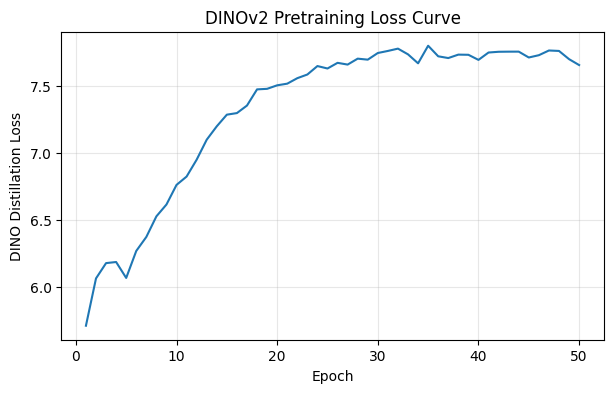

Average per-epoch time: 92.6s


In [9]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history)
plt.xlabel("Epoch"); plt.ylabel("DINO Distillation Loss"); plt.title("DINOv2 Pretraining Loss Curve")
plt.grid(alpha=0.3)
plt.savefig("/kaggle/working/dinov2_pretrain_loss.png", dpi=150, bbox_inches="tight")
plt.show()

avg_epoch_time = sum(epoch_time_history) / len(epoch_time_history)
print(f"Average per-epoch time: {avg_epoch_time:.1f}s")


## Save encoder checkpoint for Task C



In [10]:
torch.save({
    "patch_embed_state_dict": student.patch_embed.state_dict(),
    "pos_embed": student.pos_embed,
    "cls_token": student.cls_token,
    "encoder_state_dict": student.encoder.state_dict(),
    "config": CONFIG,
    "final_loss": loss_history[-1],
    "avg_epoch_time_sec": avg_epoch_time,
}, "/kaggle/working/dinov2_encoder_checkpoint.pth")

print("Saved: /kaggle/working/dinov2_encoder_checkpoint.pth")
print("Feeds Task C: use student.extract_feature_map() -> [B, embed_dim, grid, grid] into the ASPP decoder.")


Saved: /kaggle/working/dinov2_encoder_checkpoint.pth
Feeds Task C: use student.extract_feature_map() -> [B, embed_dim, grid, grid] into the ASPP decoder.
